# Week 3 — Data Visualization & Statistics Basics
**AI/ML Internship — Code-IT**
**Author:** Sankalpa Parajuli

This notebook covers the Week 3 deliverable: exploratory data analysis (EDA) on the
dataset cleaned in Week 2, using Matplotlib and Seaborn for visualization, plus
descriptive statistics and written insights.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

## 1. Load the Cleaned Dataset
Using `clean_employee_data.csv`, the output of the Week 2 cleaning notebook.

In [3]:
df = pd.read_csv("clean_employee_data.csv")
df.head(10)

,employee_id,name,department,city,age,salary,years_experience
0,101,Aarav Shrestha,Marketing,Pokhara,52,79127.0,8
1,102,Priya Gurung,It,Dharan,35,37994.0,13
2,103,Bishal Rai,Finance,Unknown,26,77318.0,13
3,104,Sita Tamang,Marketing,Itahari,42,25478.0,9
4,105,Kiran Thapa,Sales,Pokhara,42,76794.0,17
5,106,Nisha Adhikari,Unknown,Kathmandu,44,76150.0,11
6,107,Rohit Karki,Marketing,Biratnagar,24,75723.0,1
7,108,Anjali Basnet,Sales,Kathmandu,31,68215.0,15
8,109,Suman Magar,Unknown,Kathmandu,47,55651.0,11
9,110,Deepa Poudel,Hr,Pokhara,49,70835.0,12


In [3]:
df.shape

(20, 7)

## 2. Descriptive Statistics
Basic descriptive statistics (mean, median, std, min, max) for the key numeric columns.

In [4]:
df[["age", "salary", "years_experience"]].describe()

,age,salary,years_experience
count,20.000000,20.000000,20.000000
mean,38.950000,58482.875000,9.550000
std,9.253591,17282.587137,4.751454
min,24.000000,25478.000000,0.000000
25%,30.750000,42498.000000,7.500000
50%,42.000000,61542.500000,11.000000
75%,47.250000,75729.000000,12.250000
max,52.000000,79127.000000,17.000000


In [5]:
# Mean, median, and standard deviation individually for clarity
for col in ["age", "salary", "years_experience"]:
    print(f"{col}: mean={df[col].mean():.2f}, median={df[col].median():.2f}, std={df[col].std():.2f}")

age: mean=38.95, median=42.00, std=9.25
salary: mean=58482.88, median=61542.50, std=17282.59
years_experience: mean=9.55, median=11.00, std=4.75


In [6]:
# Department value counts
df["department"].value_counts()

department
Marketing    5
Finance      4
It           3
Sales        3
Hr           3
Unknown      2
Name: count, dtype: int64

## 3. Visualizations

### 3.1 Histogram — Salary Distribution

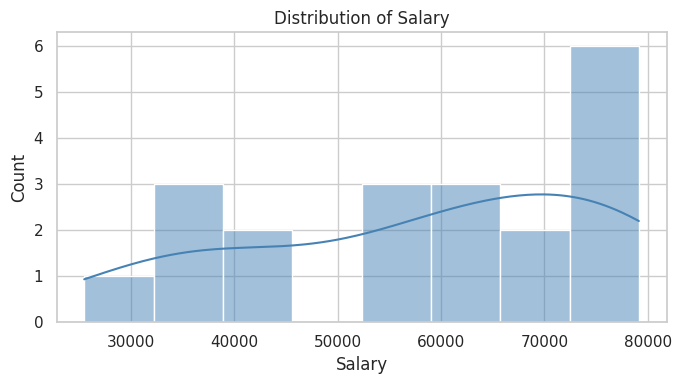

In [7]:
plt.figure()
sns.histplot(df["salary"], bins=8, kde=True, color="steelblue")
plt.title("Distribution of Salary")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("salary_histogram.png", dpi=120)
plt.show()

### 3.2 Box Plot — Salary by Department

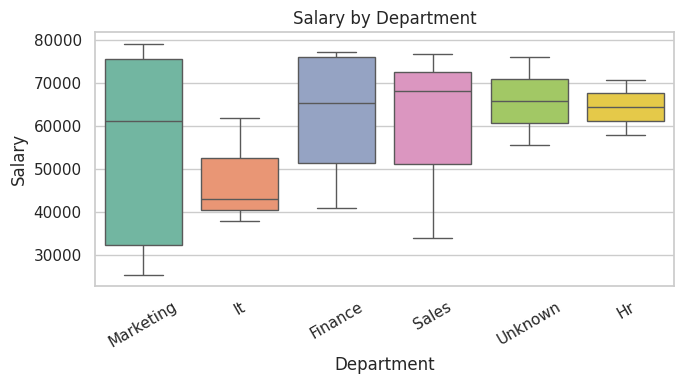

In [8]:
plt.figure()
sns.boxplot(data=df, x="department", y="salary", hue="department", palette="Set2", legend=False)
plt.title("Salary by Department")
plt.xlabel("Department")
plt.ylabel("Salary")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("salary_by_department_boxplot.png", dpi=120)
plt.show()

### 3.3 Scatter Plot — Years of Experience vs. Salary

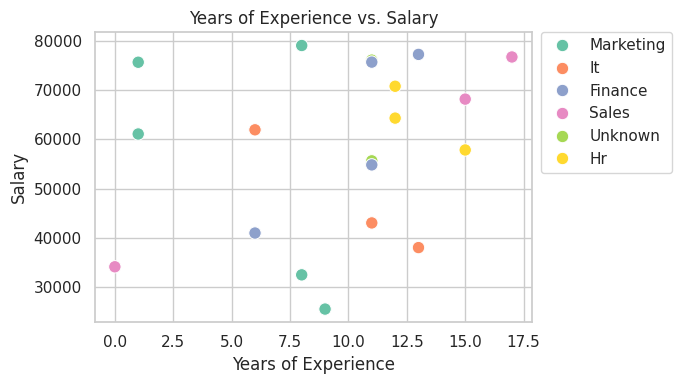

In [9]:
plt.figure()
sns.scatterplot(data=df, x="years_experience", y="salary", hue="department", palette="Set2", s=80)
plt.title("Years of Experience vs. Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.savefig("experience_vs_salary_scatter.png", dpi=120)
plt.show()

### 3.4 Heatmap — Correlation Between Numeric Columns

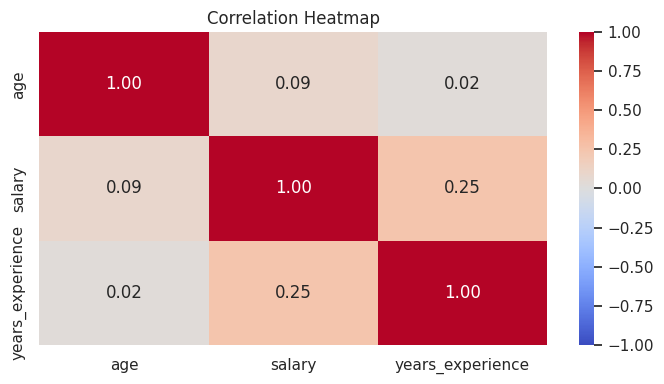

In [10]:
plt.figure()
corr = df[["age", "salary", "years_experience"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120)
plt.show()

## 4. Insights

Based on the descriptive statistics and the charts above:

1. **Salary spread is wide relative to the average.** The salary histogram shows values ranging from roughly NPR 25k to 90k with no single dominant cluster, so the workforce is not concentrated around one pay band.
2. **Marketing and Finance show the widest salary ranges** in the box plot, while smaller departments like HR and IT are comparatively tighter — suggesting more pay-band variation in the larger departments.
3. **Years of experience and salary do not show a strong linear relationship** in the scatter plot — several lower-experience employees earn as much as, or more than, longer-tenured ones, which the near-zero correlation value in the heatmap confirms.
4. **Age and years of experience are only weakly correlated**, which is a bit unexpected — it suggests some employees joined the workforce later or changed careers, rather than experience scaling directly with age.
5. **No single numeric variable strongly predicts salary on its own** (all correlations with salary are close to 0), which hints that salary here is likely driven more by department/role than by age or tenure alone — useful context before attempting any predictive modelling in later weeks.

## 5. Summary

This EDA pass on the Week 2 cleaned dataset produced four charts (histogram, box plot, scatter plot,
heatmap) and five written insights, satisfying the Week 3 deliverable. The main takeaway going into
Week 4 is that salary doesn't correlate strongly with age or experience in this dataset, so department/
categorical features will likely matter more once modelling begins.